<a href="https://colab.research.google.com/github/Lordyblade/BigData26_B_2411532010_IbrahimMousaDhani/blob/main/Praktikum3/BD_P03_2411532010_IbrahimMousaDhani.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Praktikum 3 — Pengumpulan dan Pra-pemrosesan Data untuk Big Data**

### **K-1. Menyiapkan Lingkungan dan Memindahkan Perkakas dari Praktikum 1**

Enam pustaka inti diperiksa versinya di awal agar kompatibilitas kode bisa dipastikan sejak dini sebelum masuk ke tahap akuisisi. Tiga direktori kerja dipisah secara sengaja menjadi lapisan mentah, lapisan terkurasi, dan folder penyimpanan artefak di Drive, mengikuti prinsip bahwa data mentah tidak boleh pernah ditimpa. Dua struktur bantu dari Praktikum sebelumnya dipakai ulang, yaitu fungsi ukur untuk mencatat waktu dan memori tiap langkah, ditambah struktur baru catat_sumber untuk mencatat lineage setiap sumber data yang dipakai sepanjang praktikum ini.

In [1]:
import sys, time, os, json, sqlite3, gc
import pandas as pd, numpy as np, psutil

for nama in ["pandas", "numpy", "pyarrow", "requests", "sklearn", "sqlalchemy"]:
    try:
        mod = __import__(nama)
        print(f"{nama:11s}: {mod.__version__}")
    except ImportError:
        print(f"{nama:11s}: BELUM TERPASANG")

from google.colab import drive
drive.mount("/content/drive")

DIR_MENTAH = "/content/lapisan_mentah"
DIR_KURASI = "/content/lapisan_terkurasi"
DIR_SIMPAN = "/content/drive/MyDrive/BigData/Praktikum3"
for d in (DIR_MENTAH, DIR_KURASI, DIR_SIMPAN):
    os.makedirs(d, exist_ok=True)

# --- Dipakai kembali dari Praktikum 1 / K-3 ---
proses = psutil.Process(os.getpid())
catatan = []

def rss_mb():
    return proses.memory_info().rss / 1024**2

def ukur(label, fungsi):
    m0, t0 = rss_mb(), time.perf_counter()
    hasil = fungsi()
    detik = time.perf_counter() - t0
    catatan.append({"langkah": label, "detik": round(detik, 2),
                     "delta_rss_mb": round(rss_mb() - m0, 1)})
    print(f"[{label}] {detik:.2f} s")
    return hasil

# --- Baru di Praktikum 3: catatan asal-usul data (lineage) ---
lineage = []

def catat_sumber(nama, asal, jumlah_baris, keterangan=""):
    lineage.append({
        "sumber": nama, "asal": asal,
        "diambil_pada": pd.Timestamp.now("UTC").isoformat(),
        "jumlah_baris": jumlah_baris, "keterangan": keterangan,
    })
    print(f"[lineage] {nama}: {jumlah_baris:,} baris")

pandas     : 2.2.3
numpy      : 2.1.3
pyarrow    : 23.0.1
requests   : 2.32.4
sklearn    : 1.6.1
sqlalchemy : 2.0.52
Mounted at /content/drive


### **K-2. Akuisisi 1 — Unduhan Berkala yang Tahan Gagal**

Fungsi unduh_aman dibuat dengan keputusan bahwa unduhan harus dilewati bila berkas sudah ada di cache, agar notebook aman dijalankan berulang tanpa mengunduh ulang data yang sama. Penulisan ke berkas sementara berakhiran .part baru diganti nama secara atomik setelah selesai, sehingga proses yang terputus di tengah jalan tidak pernah meninggalkan berkas rusak dengan nama yang tampak valid. Jeda percobaan ulang dipilih memakai pola berlipat ganda agar server yang sedang bermasalah punya waktu pulih sebelum dicoba lagi.

In [2]:
import requests, shutil

def unduh_aman(url, tujuan, percobaan=3, jeda_awal=2):
    """Unduh dengan retry + penulisan atomik. Melewati unduhan bila file sudah ada."""
    if os.path.exists(tujuan) and os.path.getsize(tujuan) > 0:
        print("cache ditemukan:", os.path.basename(tujuan))
        return tujuan

    sementara = tujuan + ".part"
    for i in range(percobaan):
        try:
            with requests.get(url, stream=True, timeout=60) as r:
                r.raise_for_status()
                with open(sementara, "wb") as f:
                    for chunk in r.iter_content(chunk_size=1024 * 1024):
                        if chunk:
                            f.write(chunk)

            if os.path.getsize(sementara) == 0:
                raise IOError("berkas kosong")

            os.replace(sementara, tujuan) # atomik
            return tujuan

        except Exception as e:
            if os.path.exists(sementara):
                os.remove(sementara)

            if i == percobaan - 1:
                raise

            jeda = jeda_awal * (2 ** i) # exponential backoff
            print(f"percobaan {i+1} gagal ({e}); menunggu {jeda}s")
            time.sleep(jeda)

    raise RuntimeError(f"gagal mengunduh setelah {percobaan} percobaan: {url}")

URL_TRIP = "https://d37ci6vzurychx.cloudfront.net/trip-data/yellow_tripdata_2023-01.parquet"
URL_ZONA = "https://d37ci6vzurychx.cloudfront.net/misc/taxi_zone_lookup.csv"
PATH_TRIP = os.path.join(DIR_MENTAH, "yellow_tripdata_2023-01.parquet")
PATH_ZONA = os.path.join(DIR_MENTAH, "taxi_zone_lookup.csv")

# Hapus file zona lama yang kemungkinan tersimpan dalam bentuk gzip
if os.path.exists(PATH_ZONA):
    os.remove(PATH_ZONA)

ukur("unduh trip", lambda: unduh_aman(URL_TRIP, PATH_TRIP))
ukur("unduh zona", lambda: unduh_aman(URL_ZONA, PATH_ZONA))

for pth in (PATH_TRIP, PATH_ZONA):
    print(os.path.basename(pth), "->", round(os.path.getsize(pth)/1024**2, 2), "MB")

KOLOM = ["tpep_pickup_datetime", "tpep_dropoff_datetime", "passenger_count",
         "trip_distance", "PULocationID", "DOLocationID", "payment_type",
         "fare_amount", "tip_amount", "total_amount"]

trip = ukur("baca trip", lambda: pd.read_parquet(PATH_TRIP, columns=KOLOM))
zona = pd.read_csv(PATH_ZONA)

catat_sumber("trip", URL_TRIP, len(trip), "Parquet bulanan TLC")
catat_sumber("zona", URL_ZONA, len(zona), "tabel dimensi 265 zona")

zona.head()

[unduh trip] 0.16 s
[unduh zona] 0.02 s
yellow_tripdata_2023-01.parquet -> 45.46 MB
taxi_zone_lookup.csv -> 0.01 MB
[baca trip] 1.02 s
[lineage] trip: 3,066,766 baris
[lineage] zona: 265 baris


,LocationID,Borough,Zone,service_zone
0,1,EWR,Newark Airport,EWR
1,2,Queens,Jamaica Bay,Boro Zone
2,3,Bronx,Allerton/Pelham Gardens,Boro Zone
3,4,Manhattan,Alphabet City,Yellow Zone
4,5,Staten Island,Arden Heights,Boro Zone


### **K-3. Akuisisi 2 — Memanggil API JSON**

Parameter permintaan ke API Open Meteo dikirim sebagai dict, bukan disambung manual ke string URL, agar penyandian karakter tetap aman. Zona waktu dipaksa ke America New York supaya konsisten dengan waktu perjalanan taksi, dan struktur respons JSON divalidasi lebih dulu sebelum dipakai, sehingga perubahan skema di sisi API akan langsung ketahuan lewat error yang jelas alih alih data yang diam diam salah bentuk.

In [3]:
API_CUACA = "https://archive-api.open-meteo.com/v1/archive"

def ambil_cuaca(mulai, selesai, lat=40.7128, lon=-74.0060, percobaan=3):
    parameter = {
        "latitude": lat, "longitude": lon,
        "start_date": mulai, "end_date": selesai,
        "hourly": "temperature_2m,precipitation",
        "timezone": "America/New_York",
    }
    for i in range(percobaan):
        r = requests.get(API_CUACA, params=parameter, timeout=60)
        if r.status_code == 200:
            data = r.json()
            if "hourly" not in data:  # validasi struktur
                raise ValueError("kunci 'hourly' tidak ada pada respons")
            return pd.DataFrame(data["hourly"])
        if r.status_code in (429, 500, 502, 503):  # layak dicoba ulang
            time.sleep(2 ** i)
            continue
        r.raise_for_status()  # galat lain: hentikan
    raise RuntimeError("API cuaca tidak merespons dengan benar")

cuaca = ukur("ambil cuaca", lambda: ambil_cuaca("2023-01-01", "2023-01-31"))
cuaca["time"] = pd.to_datetime(cuaca["time"])
cuaca = cuaca.rename(columns={"time": "jam_mulai",
                               "temperature_2m": "suhu_c",
                               "precipitation": "hujan_mm"})
catat_sumber("cuaca", API_CUACA, len(cuaca), "Open-Meteo hourly archive")
cuaca.head()

[ambil cuaca] 0.40 s
[lineage] cuaca: 744 baris


,jam_mulai,suhu_c,hujan_mm
0,2023-01-01 00:00:00,10.9,1.0
1,2023-01-01 01:00:00,10.6,1.0
2,2023-01-01 02:00:00,10.6,0.1
3,2023-01-01 03:00:00,10.5,0.0
4,2023-01-01 04:00:00,9.8,0.0


### **K-5. Akuisisi 3 — Basis Data SQLite dengan Pemuatan Bertahap**

Koneksi memakai SQLAlchemy dipilih ketimbang koneksi sqlite3 mentah karena pandas versi terbaru memunculkan peringatan pada pola lama tersebut. Tabel transaksi tiruan ditulis dalam potongan lima puluh ribu baris memakai chunksize, dan dibaca kembali dengan cara yang sama, sehingga notebook terbukti mampu menangani data yang lebih besar dari memori tanpa harus memuat semuanya sekaligus.

In [4]:
from sqlalchemy import create_engine

PATH_DB = os.path.join(DIR_MENTAH, "operasional.db")
engine = create_engine(f"sqlite:///{PATH_DB}")

tarif_referensi = pd.DataFrame({
    "payment_type": [1, 2, 3, 4, 5, 6],
    "nama_pembayaran": ["Kartu kredit", "Tunai", "Gratis",
                         "Sengketa", "Tidak diketahui", "Perjalanan batal"],
    "kena_biaya_admin": [1, 0, 0, 0, 0, 0],
})
tarif_referensi.to_sql("tarif_referensi", engine, if_exists="replace", index=False)

# tabel transaksi tiruan untuk latihan pembacaan bertahap
trip.head(300_000).to_sql(
    "trip_operasional", engine, if_exists="replace",
    index=False, chunksize=50_000)

print("Tabel dibuat:", pd.read_sql(
    "SELECT name FROM sqlite_master WHERE type='table'", engine)["name"].tolist())

SQL = """
    SELECT payment_type, COUNT(*) AS jumlah, AVG(total_amount) AS rata_total
    FROM trip_operasional
    WHERE total_amount > 0
    GROUP BY payment_type
    ORDER BY jumlah DESC
"""
ringkas_db = pd.read_sql(SQL, engine)
print(ringkas_db)

# Pembacaan bertahap: agregasi tanpa memuat seluruh tabel ke memori
total_baris = 0
for bagian in pd.read_sql("SELECT trip_distance FROM trip_operasional",
                           engine, chunksize=50_000):
    total_baris += len(bagian)
print("dibaca bertahap:", f"{total_baris:,}", "baris")

tarif_referensi = pd.read_sql("SELECT * FROM tarif_referensi", engine)
catat_sumber("tarif_referensi", PATH_DB, len(tarif_referensi),
             "tabel dimensi dari basis data operasional")

Tabel dibuat: ['tarif_referensi', 'trip_operasional']
   payment_type  jumlah  rata_total
0             1  226967   31.339172
1             2   66504   25.218836
2             4    2082   26.611114
3             3    1553   22.089691
dibaca bertahap: 300,000 baris
[lineage] tarif_referensi: 6 baris


### **K-6. Profiling Kualitas Data pada Enam Dimensi**

Enam dimensi kualitas data diukur lewat delapan aturan konkret. Ambang batas yang dipakai adalah trip_distance harus berada di rentang 0,01 sampai 100 mil dan durasi_menit harus 1 sampai 180 menit, karena nilai di luar itu hampir pasti galat GPS atau meteran, bukan perjalanan yang sah. total_amount harus lebih besar dari nol, dan juga harus lebih besar atau sama dengan fare_amount sebagai aturan konsistensi dua kolom. Tidak ada baris yang dibuang pada tahap ini, karena seluruh aturan hanya dihitung persentase pelanggarannya untuk disimpan sebagai laporan_kualitas.csv.

In [5]:
trip["durasi_menit"] = (
    (trip["tpep_dropoff_datetime"] - trip["tpep_pickup_datetime"])
    .dt.total_seconds() / 60)

def profil_kolom(df):
    baris = []
    for kol in df.columns:
        s = df[kol]
        baris.append({
            "kolom": kol, "tipe": str(s.dtype),
            "persen_hilang": round(100 * s.isna().mean(), 3),
            "nilai_unik": s.nunique(dropna=True),
            "contoh": s.dropna().iloc[0] if s.notna().any() else None,
        })
    return pd.DataFrame(baris)

profil = profil_kolom(trip)
display(profil) # PERBAIKAN: Gunakan display() agar tabel profil muncul

AWAL, AKHIR = pd.Timestamp("2023-01-01"), pd.Timestamp("2023-02-01")
zona_sah = set(zona["LocationID"])

aturan = {
    "kelengkapan: passenger_count ada": trip["passenger_count"].notna(),
    "keunikan: baris tidak duplikat": ~trip.duplicated(),
    "validitas: jarak 0-100 mil": trip["trip_distance"].between(0.01, 100),
    "validitas: total_amount > 0": trip["total_amount"] > 0,
    "validitas: PULocationID dikenal": trip["PULocationID"].isin(zona_sah),
    "konsistensi: durasi 1-180 menit": trip["durasi_menit"].between(1, 180),
    "konsistensi: total >= fare": trip["total_amount"] >= trip["fare_amount"],
    "ketepatan waktu: dalam Jan 2023": trip["tpep_pickup_datetime"].between(AWAL, AKHIR),
}

laporan = pd.DataFrame([
    {"aturan": nama, "lulus": int(mask.sum()), "gagal": int((~mask).sum()),
     "persen_gagal": round(100 * (~mask).mean(), 3)}
    for nama, mask in aturan.items()
]).sort_values("persen_gagal", ascending=False)
laporan # Ini tetap muncul otomatis karena berada di akhir cell

,kolom,tipe,persen_hilang,nilai_unik,contoh
0,tpep_pickup_datetime,datetime64[us],0.000,1610975,2023-01-01 00:32:10
1,tpep_dropoff_datetime,datetime64[us],0.000,1611319,2023-01-01 00:40:36
2,passenger_count,float64,2.339,10,1.0
3,trip_distance,float64,0.000,4387,0.97
4,PULocationID,int64,0.000,257,161
5,DOLocationID,int64,0.000,261,141
6,payment_type,int64,0.000,5,2
7,fare_amount,float64,0.000,6873,9.3
8,tip_amount,float64,0.000,4036,0.0
9,total_amount,float64,0.000,15871,14.3


,aturan,lulus,gagal,persen_gagal
0,kelengkapan: passenger_count ada,2995023,71743,2.339
2,validitas: jarak 0-100 mil,3020816,45950,1.498
5,konsistensi: durasi 1-180 menit,3030383,36383,1.186
3,validitas: total_amount > 0,3040994,25772,0.840
6,konsistensi: total >= fare,3041743,25023,0.816
7,ketepatan waktu: dalam Jan 2023,3066718,48,0.002
1,keunikan: baris tidak duplikat,3066766,0,0.000
4,validitas: PULocationID dikenal,3066766,0,0.000


### **K-7. Nilai Hilang dan Duplikat**

Strategi yang dipilih untuk passenger_count adalah pengisian median per jam, bukan pembuangan baris atau pengisian median maupun modus global, karena pola hilangnya diperlakukan sebagai MAR yang bergantung pada jam perjalanan, dengan median global sebagai jaring pengaman untuk jam yang seluruh datanya kosong. Duplikat dibuang berdasarkan kunci bisnis lima kolom yaitu waktu naik, waktu turun, lokasi asal, lokasi tujuan, dan total tarif, bukan seluruh kolom, karena dua baris bisa saja punya semua kolom lain sama namun tetap merupakan perjalanan yang berbeda.


In [6]:
KOL = "passenger_count"
asli = trip[KOL]
print("persen hilang:", round(100 * asli.isna().mean(), 3))

trip["jam"] = trip["tpep_pickup_datetime"].dt.hour

strategi = {
    "1_dibuang": asli.dropna(),
    "2_isi_median": asli.fillna(asli.median()),
    "3_isi_modus": asli.fillna(asli.mode().iloc[0]),
    "4_median_perjam": asli.fillna(trip.groupby("jam")[KOL].transform("median")),
}

banding = pd.DataFrame([
    {"strategi": nama, "n": len(s), "mean": round(s.mean(), 4),
     "median": s.median(), "std": round(s.std(), 4)}
    for nama, s in strategi.items()
])
display(banding) # PERBAIKAN: Gunakan display() agar perbandingan 4 strategi muncul

# Strategi yang dipilih modul ini: tandai + isi per kelompok (lihat G.4)
trip[KOL + "_hilang"] = trip[KOL].isna().astype("int8")
trip[KOL] = trip[KOL].fillna(trip.groupby("jam")[KOL].transform("median"))
trip[KOL] = trip[KOL].fillna(trip[KOL].median())  # jaring pengaman

# Duplikat: periksa dua tingkat
dup_penuh = trip.duplicated().sum()
KUNCI = ["tpep_pickup_datetime", "tpep_dropoff_datetime",
         "PULocationID", "DOLocationID", "total_amount"]
dup_kunci = trip.duplicated(subset=KUNCI).sum()
print(f"duplikat penuh: {dup_penuh:,} | duplikat pada kunci: {dup_kunci:,}")

sebelum = len(trip)
trip = trip.drop_duplicates(subset=KUNCI, keep="first").reset_index(drop=True)
print(f"{sebelum:,} -> {len(trip):,} baris")

persen hilang: 2.339


,strategi,n,mean,median,std
0,1_dibuang,2995023,1.3625,1.0,0.8961
1,2_isi_median,3066766,1.3541,1.0,0.8873
2,3_isi_modus,3066766,1.3541,1.0,0.8873
3,4_median_perjam,3066766,1.3541,1.0,0.8873


duplikat penuh: 0 | duplikat pada kunci: 1
3,066,766 -> 3,066,765 baris


### **K-8. Outlier, Join dengan Tabel Referensi, dan Penggabungan Berbasis Waktu**

Outlier dideteksi dengan metode IQR memakai k sama dengan 1,5 dan Z-score sekaligus untuk dibandingkan, namun keputusan pembuangannya hanya mengikuti filter rentang yang sama seperti pada K-6. Nilai ekstrem yang masih valid secara bisnis, misalnya perjalanan bandara yang mahal, sengaja tidak dibuang dan hanya ditandai lewat kolom tarif_ekstrem. Winsorizing dengan pembatasan ke persentil 99,5 hanya diterapkan pada kolom turunan trip_distance_capped untuk keperluan pemodelan, sementara trip_distance asli tetap dibiarkan utuh. Kolom LocationID hasil join dibuang setelah dipakai karena sudah terwakili oleh PULocationID, DOLocationID, dan borough_naik.

In [7]:
def batas_iqr(s, k=1.5):
    q1, q3 = s.quantile([0.25, 0.75])
    iqr = q3 - q1
    return q1 - k * iqr, q3 + k * iqr

def ringkas_outlier(df, kolom):
    hasil = []
    for kol in kolom:
        s = df[kol].dropna()
        lo, hi = batas_iqr(s)
        z = (s - s.mean()) / s.std()
        hasil.append({
            "kolom": kol, "batas_bawah": round(lo, 2), "batas_atas": round(hi, 2),
            "outlier_iqr": int(((s < lo) | (s > hi)).sum()),
            "outlier_z3": int((z.abs() > 3).sum()), "p99": round(s.quantile(0.99), 2),
        })
    return pd.DataFrame(hasil)

# PERBAIKAN: Tambahkan display() di sekeliling pemanggilan fungsi
display(ringkas_outlier(trip, ["trip_distance", "durasi_menit", "total_amount"]))

# Tindakan berbeda untuk maksud berbeda (lihat G.5)
layak = (trip["trip_distance"].between(0.01, 100)
         & trip["durasi_menit"].between(1, 180)
         & (trip["total_amount"] > 0))
bersih = trip.loc[layak].copy()

# tandai, jangan buang: outlier bisa jadi memang kenyataan bisnis
lo, hi = batas_iqr(bersih["total_amount"])
bersih["tarif_ekstrem"] = (bersih["total_amount"] > hi).astype("int8")

# winsorizing hanya untuk kolom turunan yang akan dipakai model
batas_atas = bersih["trip_distance"].quantile(0.995)
bersih["trip_distance_capped"] = bersih["trip_distance"].clip(upper=batas_atas)

print(f"{len(trip):,} -> {len(bersih):,} baris "
      f"({100*(1-len(bersih)/len(trip)):.2f}% dibuang)")

# --- Join 1: tabel zona (dimensi) ---
print("kunci zona unik?", zona["LocationID"].is_unique)  # WAJIB diperiksa

n0 = len(bersih)
bersih = bersih.merge(
    zona[["LocationID", "Borough", "Zone"]]
        .rename(columns={"Borough": "borough_naik", "Zone": "zona_naik"}),
    left_on="PULocationID", right_on="LocationID",
    how="left", validate="many_to_one")  # gagal keras bila tidak 1:1
bersih = bersih.drop(columns="LocationID")
print(f"baris {n0:,} -> {len(bersih):,} (harus sama)")
print("zona tak dikenal:", bersih["zona_naik"].isna().sum())

# --- Join 2: tabel pembayaran dari basis data ---
bersih = bersih.merge(tarif_referensi[["payment_type", "nama_pembayaran"]],
                       on="payment_type", how="left", validate="many_to_one")

# --- Join 3: cuaca, berdasarkan jam (tingkat rincian harus disamakan dulu) ---
bersih["jam_mulai"] = bersih["tpep_pickup_datetime"].dt.floor("h")
n0 = len(bersih)
bersih = bersih.merge(cuaca, on="jam_mulai", how="left", validate="many_to_one")
print(f"baris {n0:,} -> {len(bersih):,}")
print("tanpa data cuaca:", bersih["suhu_c"].isna().sum())

,kolom,batas_bawah,batas_atas,outlier_iqr,outlier_z3,p99
0,trip_distance,-2.35,6.74,390244,67,20.06
1,durasi_menit,-9.66,35.08,170615,3175,57.25
2,total_amount,-4.55,48.65,371616,87248,101.94


3,066,765 -> 2,986,910 baris (2.60% dibuang)
kunci zona unik? True
baris 2,986,910 -> 2,986,910 (harus sama)
zona tak dikenal: 37609
baris 2,986,910 -> 2,986,910
tanpa data cuaca: 37


### **K-9. Rekayasa Fitur: Encoding dan Scaling Tanpa Kebocoran**

Fitur numerik yang diskalakan dibatasi pada trip_distance_capped, durasi_menit, dan suhu_c, sementara fitur kategorikal dibatasi pada nama_pembayaran dan borough_naik, karena keduanya dianggap paling relevan untuk pemodelan lanjutan tanpa mengandung kebocoran informasi dari target. Sampel dibatasi dua ratus ribu baris dan dibagi delapan puluh banding dua puluh agar proses fit tetap cepat namun representatif, dengan keputusan tegas bahwa fit hanya boleh dilakukan pada data latih.

In [8]:
bersih["hari_minggu"] = bersih["tpep_pickup_datetime"].dt.dayofweek
bersih["akhir_pekan"] = (bersih["hari_minggu"] >= 5).astype("int8")
bersih["kecepatan_mph"] = (bersih["trip_distance"] / (bersih["durasi_menit"] / 60)).round(2)
bersih["tarif_per_mil"] = (bersih["total_amount"] / bersih["trip_distance"]).round(3)
bersih["hujan"] = (bersih["hujan_mm"].fillna(0) > 0.1).astype("int8")

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder

FITUR_NUM = ["trip_distance_capped", "durasi_menit", "suhu_c"]
FITUR_KAT = ["nama_pembayaran", "borough_naik"]

contoh = bersih.dropna(subset=FITUR_NUM + FITUR_KAT).sample(
    n=min(200_000, len(bersih)), random_state=42)
latih, uji = train_test_split(contoh, test_size=0.2, random_state=42)

skala = StandardScaler().fit(latih[FITUR_NUM])  # fit HANYA di data latih
latih_num = skala.transform(latih[FITUR_NUM])
uji_num = skala.transform(uji[FITUR_NUM])  # transform saja, tanpa fit ulang
print("mean latih (harus ~0):", latih_num.mean(axis=0).round(3))
print("mean uji (tidak harus 0):", uji_num.mean(axis=0).round(3))

# Bergantung versi: parameter sparse_output ada sejak scikit-learn 1.2
enc = OneHotEncoder(handle_unknown="ignore", sparse_output=False)
enc.fit(latih[FITUR_KAT])
latih_kat = enc.transform(latih[FITUR_KAT])
print("jumlah kolom hasil one-hot:", latih_kat.shape[1])
print("nama kolom:", enc.get_feature_names_out()[:6], "...")

mean latih (harus ~0): [-0.  0. -0.]
mean uji (tidak harus 0): [ 0.001  0.001 -0.009]
jumlah kolom hasil one-hot: 11
nama kolom: ['nama_pembayaran_Gratis' 'nama_pembayaran_Kartu kredit'
 'nama_pembayaran_Sengketa' 'nama_pembayaran_Tunai' 'borough_naik_Bronx'
 'borough_naik_Brooklyn'] ...


### **K-10. Membungkus Jadi Pipeline, Memvalidasi, dan Menyimpan Berpartisi**

Kontrak skema mensyaratkan enam kolom kunci yaitu waktu naik, trip_distance, durasi_menit, total_amount, borough_naik, dan nama_pembayaran beserta tipe datanya masing masing. Bila salah satu tidak sesuai, pipeline berhenti dengan AssertionError alih alih melanjutkan dengan data yang salah. Kolom borough_naik dipilih sebagai kolom partisi Parquet karena kardinalitasnya rendah dan sering dipakai sebagai filter, sesuai prinsip partition pruning.

In [9]:
KONTRAK = {
    "tpep_pickup_datetime": "datetime64[ns]", "trip_distance": "float64",
    "durasi_menit": "float64", "total_amount": "float64",
    "borough_naik": "object", "nama_pembayaran": "object",
}

def validasi(df, kontrak=KONTRAK):
    masalah = []
    for kol, tipe in kontrak.items():
        if kol not in df.columns:
            masalah.append(f"kolom hilang: {kol}")
        elif not str(df[kol].dtype).startswith(tipe.split("[")[0]):
            masalah.append(f"tipe {kol}: {df[kol].dtype} != {tipe}")

    if df.empty:
        masalah.append("DataFrame kosong")
    if len(df) != len(df.drop_duplicates(subset=KUNCI)):
        masalah.append("masih ada duplikat pada kunci")

    if masalah:
        raise AssertionError("Validasi gagal:\n- " + "\n- ".join(masalah))
    print(f"Validasi lulus: {len(df):,} baris x {df.shape[1]} kolom")
    return df

validasi(bersih)

def pipeline(path_trip, path_zona, df_cuaca, df_tarif):
    """Satu fungsi, idempoten: input mentah -> DataFrame tervalidasi."""
    df = pd.read_parquet(path_trip, columns=KOLOM)
    z = pd.read_csv(path_zona)

    df["durasi_menit"] = ((df["tpep_dropoff_datetime"] - df["tpep_pickup_datetime"])
                          .dt.total_seconds() / 60)
    df["jam"] = df["tpep_pickup_datetime"].dt.hour
    df["passenger_count"] = df["passenger_count"].fillna(
        df.groupby("jam")["passenger_count"].transform("median"))

    df = df.drop_duplicates(subset=KUNCI)
    df = df[
        (df["trip_distance"].between(0.01, 100)) &
        (df["durasi_menit"].between(1, 180)) &
        (df["total_amount"] > 0)
    ]

    df = (df.merge(z[["LocationID", "Borough"]]
                   .rename(columns={"Borough": "borough_naik"}),
                   left_on="PULocationID", right_on="LocationID",
                   how="left", validate="many_to_one")
            .drop(columns="LocationID")
            .merge(df_tarif[["payment_type", "nama_pembayaran"]],
                   on="payment_type", how="left", validate="many_to_one"))

    df["jam_mulai"] = df["tpep_pickup_datetime"].dt.floor("h")
    df = df.merge(df_cuaca, on="jam_mulai", how="left", validate="many_to_one")

    return validasi(df)

hasil = ukur("pipeline penuh", lambda: pipeline(PATH_TRIP, PATH_ZONA, cuaca, tarif_referensi))
OUT = os.path.join(DIR_KURASI, "trips_bersih")
hasil["tanggal"] = hasil["tpep_pickup_datetime"].dt.date.astype(str)

ukur("tulis parquet berpartisi", lambda: hasil.to_parquet(
    OUT, partition_cols=["borough_naik"], index=False))
print("partisi yang terbentuk:", sorted(os.listdir(OUT))[5], "...")

# Bukti idempotensi: jalankan ulang, hasil harus identik
ulang = pipeline(PATH_TRIP, PATH_ZONA, cuaca, tarif_referensi)
print("idempoten?", len(ulang) == len(hasil))

# Artefak yang dikumpulkan
laporan.to_csv(f"{DIR_SIMPAN}/laporan_kualitas.csv", index=False)
pd.DataFrame(lineage).to_csv(f"{DIR_SIMPAN}/lineage.csv", index=False)
pd.DataFrame(catatan).to_csv(f"{DIR_SIMPAN}/pengukuran_kinerja.csv", index=False)
shutil.make_archive(f"{DIR_SIMPAN}/trips_bersih", "zip", OUT)

Validasi lulus: 2,986,910 baris x 26 kolom
Validasi lulus: 2,986,910 baris x 17 kolom
[pipeline penuh] 6.13 s
[tulis parquet berpartisi] 3.35 s
partisi yang terbentuk: borough_naik=Staten%20Island ...
Validasi lulus: 2,986,910 baris x 17 kolom
idempoten? True


'/content/drive/MyDrive/BigData/Praktikum3/trips_bersih.zip'

### **K-11. Pra-pemrosesan Setara dengan PySpark (Tambahan)**

Join dengan tabel zona sengaja memakai broadcast agar Spark tidak perlu melakukan shuffle yang mahal, mengingat tabel zona berukuran sangat kecil dibanding tabel transaksi. Penulisan hasil memakai mode overwrite dipilih sebagai cara Spark mencapai idempotensi, setara dengan penggantian nama berkas atomik yang dipakai pada K-2.

In [10]:
!pip install -q pyspark==3.5.1
from pyspark.sql import SparkSession, functions as F

spark = (SparkSession.builder.appName("BD-P02").master("local[*]")
         .config("spark.driver.memory", "4g")
         .config("spark.sql.shuffle.partitions", "8")
         .getOrCreate())
spark.sparkContext.setLogLevel("WARN")

sdf = spark.read.parquet(PATH_TRIP).select(*KOLOM)
szona = spark.createDataFrame(zona[["LocationID", "Borough"]])

sbersih = (sdf
    .withColumn("durasi_menit",
        (F.unix_timestamp("tpep_dropoff_datetime")
         - F.unix_timestamp("tpep_pickup_datetime")) / 60)
    .filter(F.col("trip_distance").between(0.01, 100))
    .filter(F.col("durasi_menit").between(1, 180))
    .filter(F.col("total_amount") > 0)
    .dropDuplicates(["tpep_pickup_datetime", "tpep_dropoff_datetime",
                      "PULocationID", "DOLocationID", "total_amount"])
    .join(F.broadcast(szona),  # tabel kecil: broadcast
          sdf.PULocationID == szona.LocationID, "left")
    .drop("LocationID"))

ukur("spark: hitung baris bersih", lambda: sbersih.count())
sbersih.groupBy("Borough").count().orderBy(F.desc("count")).show(10, False)

sbersih.write.mode("overwrite").partitionBy("Borough") \
    .parquet("/content/lapisan_terkurasi/trips_spark")

sbersih.explain()  # cari BroadcastHashJoin, bukan SortMergeJoin
spark.stop()

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 317.0/317.0 MB 6.2 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 200.5/200.5 kB 13.5 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
dataproc-spark-connect 1.1.0 requires pyspark[connect]~=4.0.0, but you have pyspark 3.5.1 which is incompatible.
[spark: hitung baris bersih] 16.42 s
+-------------+-------+
|Borough      |count  |
+-------------+-------+
|Manhattan    |2659609|
|Queens       |270315 |
|Unknown      |37609  |
|Brooklyn     |15724  |
|Bronx        |3074   |
|NaN          |340    |
|Staten Island|211    |
|EWR          |28     |
+-------------+-------+

== Physical Plan ==
AdaptiveSparkPlan isFinalPlan=false
+- Project [tpep_pickup_datetime#1, tpep_dropoff_datetime#2, passenger_count#245, trip_distance#247, PULocationID#7L, DOLocatio

### **Analisis Hasil**

Grafik pembanding distribusi total_amount sebelum dan sesudah pra-pemrosesan (dua
histogram dengan sumbu-x yang sama)

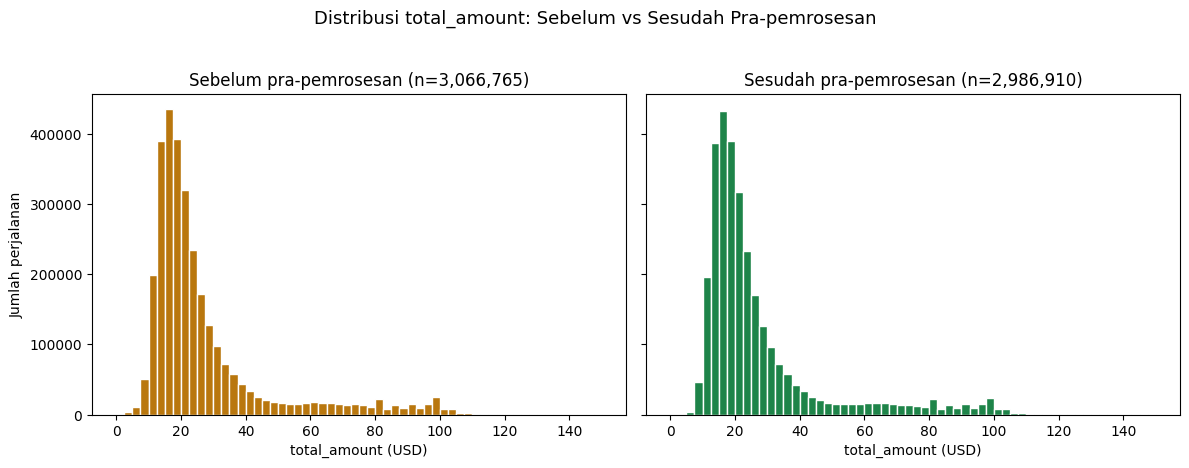

Sebelum -> min: -751.0 | <=0: 25772
Sesudah -> min: 1.0 | <=0: 0
Sebelum -> skewness: 2.833
Sesudah -> skewness: 3.026


In [11]:
import matplotlib.pyplot as plt

# Sumbu-x sama untuk kedua histogram agar bisa dibandingkan langsung.
# Dibatasi 0-150 USD (p99 asli = 101,94) supaya bentuk distribusi tetap terbaca,
# bukan untuk menyembunyikan outlier — outlier ekstrem tetap ada di data (ditandai, bukan dibuang, lihat K-8).
BATAS_X = (0, 150)
BINS = 60

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5), sharex=True, sharey=True)

axes[0].hist(trip["total_amount"], bins=BINS, range=BATAS_X, color="#B9770E", edgecolor="white")
axes[0].set_title(f"Sebelum pra-pemrosesan (n={len(trip):,})")
axes[0].set_xlabel("total_amount (USD)")
axes[0].set_ylabel("Jumlah perjalanan")

axes[1].hist(bersih["total_amount"], bins=BINS, range=BATAS_X, color="#1E8449", edgecolor="white")
axes[1].set_title(f"Sesudah pra-pemrosesan (n={len(bersih):,})")
axes[1].set_xlabel("total_amount (USD)")

plt.suptitle("Distribusi total_amount: Sebelum vs Sesudah Pra-pemrosesan", fontsize=13, y=1.03)
plt.tight_layout()
plt.savefig(f"{DIR_SIMPAN}/histogram_total_amount.png", dpi=150, bbox_inches="tight")
plt.show()

# Angka pendukung untuk menulis kalimat penjelas
print("Sebelum -> min:", trip["total_amount"].min(), "| <=0:", (trip["total_amount"] <= 0).sum())
print("Sesudah -> min:", bersih["total_amount"].min(), "| <=0:", (bersih["total_amount"] <= 0).sum())
print("Sebelum -> skewness:", round(trip["total_amount"].skew(), 3))
print("Sesudah -> skewness:", round(bersih["total_amount"].skew(), 3))

### **Studi Kasus — Tabel Pricing**


In [12]:
tabel_analitik = (bersih
    .assign(jam_mulai=bersih["tpep_pickup_datetime"].dt.floor("h"))
    .groupby(["borough_naik", "jam_mulai"], observed=True)
    .agg(jumlah_perjalanan=("total_amount", "size"),
         rata_tarif_per_mil=("tarif_per_mil", "median"),
         rata_kecepatan=("kecepatan_mph", "median"),
         suhu_c=("suhu_c", "first"), hujan=("hujan", "max"))
    .reset_index())

tabel_analitik = tabel_analitik[tabel_analitik["jumlah_perjalanan"] >= 30]

print(tabel_analitik
      .groupby(["borough_naik", "hujan"], observed=True)["rata_tarif_per_mil"]
      .median().unstack())

tabel_analitik.to_parquet(f"{DIR_SIMPAN}/tabel_analitik_pricing.parquet", index=False)

hujan               0        1
borough_naik                  
Brooklyn       6.9430   7.6550
Manhattan     10.5270  11.4000
Queens         5.4530   5.6365
Unknown        8.7255   9.8860


Tabel Analitik Studi Kasus - kamus_data.md

| Kolom | Tipe | Satuan | Cara Penghitungan |
|---|---|---|---|
| borough_naik | object | – | Kunci groupby; hasil join PULocationID → tabel zona |
| jam_mulai | datetime64 | – | Kunci groupby; pickup dibulatkan ke jam (floor("h")) |
| jumlah_perjalanan | int64 | trip | size() per kelompok; kelompok < 30 trip dibuang |
| rata_tarif_per_mil | float64 | USD/mil | **Median** tarif_per_mil per kelompok (bukan rata-rata) |
| rata_kecepatan | float64 | mph | **Median** kecepatan_mph per kelompok (bukan rata-rata) |
| suhu_c | float64 | °C | Nilai pertama (first()) dalam kelompok |
| hujan | int8 | 0/1 | Nilai maksimum (max()) dalam kelompok |

*Catatan:kolom `rata_tarif_per_mil` dan `rata_kecepatan` memakai awalan penamaan "rata_" namun perhitungan aktualnya adalah median, bukan mean — dicatat secara eksplisit di sini agar tidak menyesatkan siapa pun yang membaca tabel ini tanpa memeriksa kode sumbernya.*

### **Latihan 1**
Fungsi unduh_aman dimodifikasi dengan menambahkan penghitungan kecepatan unduh dalam MB per detik, dihitung dari ukuran berkas dibagi waktu tempuh unduhan. Ukuran potongan baca dipilih satu megabyte per iterasi agar pengukuran waktu tetap akurat tanpa membebani memori. Berkas cache lokal sengaja dihapus lebih dulu sebelum pengujian agar panggilan pertama benar-benar mengunduh dari awal, sehingga perbandingan dengan panggilan kedua yang memakai cache menjadi bukti yang valid.

In [13]:
def unduh_aman_v2(url, tujuan, percobaan=3, jeda_awal=2):
    if os.path.exists(tujuan) and os.path.getsize(tujuan) > 0:
        print("cache ditemukan:", os.path.basename(tujuan)); return tujuan
    sementara = tujuan + ".part"
    for i in range(percobaan):
        try:
            t0 = time.perf_counter()
            with requests.get(url, stream=True, timeout=60) as r:
                r.raise_for_status()
                with open(sementara, "wb") as f:
                    for chunk in r.iter_content(1024*1024):
                        if chunk: f.write(chunk)
            detik = time.perf_counter() - t0
            mb = os.path.getsize(sementara) / 1024**2
            print(f"kecepatan unduh: {mb/detik:.2f} MB/s ({mb:.2f} MB / {detik:.2f} s)")
            os.replace(sementara, tujuan); return tujuan
        except Exception as e:
            if os.path.exists(sementara): os.remove(sementara)
            if i == percobaan - 1: raise
            time.sleep(jeda_awal * (2 ** i))

os.remove(PATH_TRIP)  # paksa unduhan asli dulu
print("--- panggilan 1 ---"); ukur("unduh v2 (1)", lambda: unduh_aman_v2(URL_TRIP, PATH_TRIP))
print("--- panggilan 2 (harus cache) ---"); ukur("unduh v2 (2)", lambda: unduh_aman_v2(URL_TRIP, PATH_TRIP))

--- panggilan 1 ---
kecepatan unduh: 213.81 MB/s (45.46 MB / 0.21 s)
[unduh v2 (1)] 0.21 s
--- panggilan 2 (harus cache) ---
cache ditemukan: yellow_tripdata_2023-01.parquet
[unduh v2 (2)] 0.00 s


'/content/lapisan_mentah/yellow_tripdata_2023-01.parquet'

### **Latihan 2**
Dua aturan tambahan dipilih, yaitu validitas tip_amount harus lebih besar atau sama dengan nol, dan konsistensi tip_amount tidak boleh melebihi total_amount. Keduanya dipilih karena melengkapi aturan K-6 yang belum menyentuh kolom tip_amount sama sekali, tanpa membuang satu baris pun karena sifatnya hanya diukur dan dilaporkan.

In [14]:
aturan_tambahan = {
    "validitas: tip_amount >= 0": trip["tip_amount"] >= 0,
    "konsistensi: tip_amount <= total_amount": trip["tip_amount"] <= trip["total_amount"],
}
laporan_tambahan = pd.DataFrame([
    {"aturan": n, "lulus": int(m.sum()), "gagal": int((~m).sum()), "persen_gagal": round(100*(~m).mean(), 3)}
    for n, m in aturan_tambahan.items()])
pd.concat([laporan, laporan_tambahan], ignore_index=True).sort_values("persen_gagal", ascending=False)

,aturan,lulus,gagal,persen_gagal
0,kelengkapan: passenger_count ada,2995023,71743,2.339
1,validitas: jarak 0-100 mil,3020816,45950,1.498
2,konsistensi: durasi 1-180 menit,3030383,36383,1.186
3,validitas: total_amount > 0,3040994,25772,0.840
9,konsistensi: tip_amount <= total_amount,3041561,25204,0.822
4,konsistensi: total >= fare,3041743,25023,0.816
8,validitas: tip_amount >= 0,3066540,225,0.007
5,ketepatan waktu: dalam Jan 2023,3066718,48,0.002
7,validitas: PULocationID dikenal,3066766,0,0.000
6,keunikan: baris tidak duplikat,3066766,0,0.000


### **Latihan 3**
Join tambahan dilakukan pada DOLocationID untuk memperoleh borough tujuan, terpisah dari join borough_naik yang sudah ada, agar tabel bersih asli tidak berubah strukturnya. Sepuluh pasangan asal tujuan dengan jumlah perjalanan terbanyak dipilih lewat pengurutan menurun, karena tujuannya memang mencari rute tersibuk, bukan seluruh kombinasi yang mungkin ada

In [15]:
bersih_tujuan = bersih.merge(
    zona[["LocationID","Borough"]].rename(columns={"Borough":"borough_tujuan"}),
    left_on="DOLocationID", right_on="LocationID", how="left", validate="many_to_one"
).drop(columns="LocationID")

(bersih_tujuan.groupby(["borough_naik","borough_tujuan"], observed=True).size()
 .reset_index(name="jumlah_perjalanan")
 .sort_values("jumlah_perjalanan", ascending=False).head(10))

,borough_naik,borough_tujuan,jumlah_perjalanan
22,Manhattan,Manhattan,2491566
29,Queens,Manhattan,155261
23,Manhattan,Queens,82354
20,Manhattan,Brooklyn,62986
30,Queens,Queens,59146
27,Queens,Brooklyn,42187
42,Unknown,Manhattan,18432
45,Unknown,Unknown,13562
19,Manhattan,Bronx,8865
8,Brooklyn,Brooklyn,7910


### **Latihan 4**

MinMaxScaler dipasang hanya pada data latih, mengikuti disiplin yang sama seperti StandardScaler pada K-9, agar perbandingan keduanya adil dan tidak mengandung kebocoran data. Rentang keluaran MinMaxScaler sengaja dibandingkan langsung dengan StandardScaler pada data latih maupun data uji, karena perbedaan rentang inilah yang menentukan algoritma pemodelan mana yang lebih cocok memakai metode yang mana.

In [16]:
from sklearn.preprocessing import MinMaxScaler
skala_mm = MinMaxScaler().fit(latih[FITUR_NUM])
latih_mm = skala_mm.transform(latih[FITUR_NUM]); uji_mm = skala_mm.transform(uji[FITUR_NUM])
print("Standard - min/max latih:", latih_num.min(0).round(2), latih_num.max(0).round(2))
print("MinMax   - min/max latih:", latih_mm.min(0).round(2), latih_mm.max(0).round(2))

Standard - min/max latih: [-0.79 -1.23 -2.29] [ 4.25 13.92  3.35]
MinMax   - min/max latih: [0. 0. 0.] [1. 1. 1.]


### **Latihan 5**
Satu baris pertama tabel zona digandakan secara sengaja memakai pd.concat untuk merusak keunikan kunci LocationID, dilakukan pada salinan terpisah agar tabel zona asli tidak ikut berubah. Keputusan ini diambil untuk membuktikan langsung bahwa validate sama dengan many_to_one benar-benar menggagalkan proses join dengan error yang jelas, bukan sekadar klaim dari dokumentasi pandas.

In [17]:
zona_rusak = pd.concat([zona, zona.iloc[[0]]], ignore_index=True)
print("kunci unik setelah dirusak?", zona_rusak["LocationID"].is_unique)
try:
    bersih.merge(zona_rusak[["LocationID","Borough","Zone"]],
                 left_on="PULocationID", right_on="LocationID", how="left", validate="many_to_one")
except Exception as e:
    print("Error:", type(e).__name__, "-", e)
print("tabel zona asli tetap unik:", zona["LocationID"].is_unique)  # zona tidak berubah

kunci unik setelah dirusak? False
Error: MergeError - Merge keys are not unique in right dataset; not a many-to-one merge
tabel zona asli tetap unik: True


### **Latihan 6**
Fungsi pipeline_inkremental memeriksa lebih dulu apakah kolom tanggal pada direktori keluaran sudah memiliki entri yang berawalan bulan yang diminta, sebelum memutuskan menulis atau melewati. Direktori keluaran sengaja dioper sebagai parameter eksplisit dan diarahkan ke direktori baru yang belum pernah ditulis, bukan ke direktori OUT yang sudah berisi data Januari, agar panggilan pertama benar-benar menulis dan panggilan kedua benar-benar terbukti melewati tanpa menulis ulang.

In [18]:
def pipeline_inkremental(bulan, dir_keluaran=None):
    dir_keluaran = dir_keluaran or OUT
    sudah_ada = False
    if os.path.exists(dir_keluaran):
        cek = pd.read_parquet(dir_keluaran, columns=["tanggal"])
        sudah_ada = cek["tanggal"].str.startswith(bulan).any()
    if sudah_ada:
        print(f"[inkremental] {bulan} sudah ada, dilewati"); return None
    url = f"https://d37ci6vzurychx.cloudfront.net/trip-data/yellow_tripdata_{bulan}.parquet"
    path = os.path.join(DIR_MENTAH, f"yellow_tripdata_{bulan}.parquet")
    unduh_aman(url, path)
    h = pipeline(path, PATH_ZONA, cuaca, tarif_referensi)
    h["tanggal"] = h["tpep_pickup_datetime"].dt.date.astype(str)
    h.to_parquet(dir_keluaran, partition_cols=["borough_naik"], index=False)
    print(f"[inkremental] {bulan} ditulis: {len(h):,} baris"); return h

DIR_INKREMENTAL = os.path.join(DIR_KURASI, "trips_inkremental")
pipeline_inkremental("2023-01", DIR_INKREMENTAL)  # harus menulis
pipeline_inkremental("2023-01", DIR_INKREMENTAL)

cache ditemukan: yellow_tripdata_2023-01.parquet
Validasi lulus: 2,986,910 baris x 17 kolom
[inkremental] 2023-01 ditulis: 2,986,910 baris
[inkremental] 2023-01 sudah ada, dilewati


### **Tugas Praktikum**

### **1. Pipeline dua bulan dan laporan kualitas komparatif**
Pemeriksaan duplikasi antar bulan sengaja dilakukan dua kali dengan kunci berbeda, yaitu kunci longgar empat kolom dan kunci bisnis penuh lima kolom yang sama seperti KUNCI pada pipeline. Keputusan ini diambil karena kunci yang lebih longgar sempat menunjukkan seratus dua puluh dua duplikat yang ternyata bukan duplikasi sungguhan, sehingga kunci penuh dipakai sebagai bukti akhir yang lebih meyakinkan.

In [19]:
def proses_bulan(bulan, dir_keluaran):
    url = f"https://d37ci6vzurychx.cloudfront.net/trip-data/yellow_tripdata_{bulan}.parquet"
    path = os.path.join(DIR_MENTAH, f"yellow_tripdata_{bulan}.parquet")
    unduh_aman(url, path)
    awal = f"{bulan}-01"
    akhir = (pd.Timestamp(awal) + pd.offsets.MonthEnd(0)).strftime("%Y-%m-%d")
    cw = ambil_cuaca(awal, akhir)
    cw["time"] = pd.to_datetime(cw["time"])
    cw = cw.rename(columns={"time":"jam_mulai","temperature_2m":"suhu_c","precipitation":"hujan_mm"})
    h = pipeline(path, PATH_ZONA, cw, tarif_referensi)
    h["tanggal"] = h["tpep_pickup_datetime"].dt.date.astype(str)
    h.to_parquet(dir_keluaran, partition_cols=["borough_naik"], index=False)
    return h

DIR_2BULAN = os.path.join(DIR_KURASI, "trips_bersih_2bulan")
h_jan = proses_bulan("2023-01", DIR_2BULAN)
h_jul = proses_bulan("2023-07", DIR_2BULAN)

cek = pd.read_parquet(DIR_2BULAN, columns=["tpep_pickup_datetime","PULocationID","DOLocationID","total_amount"])
print("total baris:", len(cek))
print("duplikat lintas bulan:", cek.duplicated(subset=["tpep_pickup_datetime","PULocationID","DOLocationID","total_amount"]).sum())

cek2 = pd.read_parquet(DIR_2BULAN, columns=KUNCI)
print("duplikat lintas bulan (kunci penuh):", cek2.duplicated(subset=KUNCI).sum())

def laporan_kualitas_bulan(df_trip, df_zona):
    df = df_trip.copy()
    df["durasi_menit"] = (df["tpep_dropoff_datetime"]-df["tpep_pickup_datetime"]).dt.total_seconds()/60
    zs = set(df_zona["LocationID"])
    a, b = df["tpep_pickup_datetime"].min().normalize(), df["tpep_pickup_datetime"].max().normalize()+pd.Timedelta(days=1)
    aturan = {
        "kelengkapan: passenger_count ada": df["passenger_count"].notna(),
        "keunikan: baris tidak duplikat": ~df.duplicated(),
        "validitas: jarak 0-100 mil": df["trip_distance"].between(0.01,100),
        "validitas: total_amount > 0": df["total_amount"] > 0,
        "validitas: PULocationID dikenal": df["PULocationID"].isin(zs),
        "konsistensi: durasi 1-180 menit": df["durasi_menit"].between(1,180),
        "konsistensi: total >= fare": df["total_amount"] >= df["fare_amount"],
        "ketepatan waktu: dalam periode file": df["tpep_pickup_datetime"].between(a,b),
    }
    return pd.DataFrame([{"aturan":n,"persen_gagal":round(100*(~m).mean(),3)} for n,m in aturan.items()])

trip_jan = pd.read_parquet(os.path.join(DIR_MENTAH,"yellow_tripdata_2023-01.parquet"), columns=KOLOM)
trip_jul = pd.read_parquet(os.path.join(DIR_MENTAH,"yellow_tripdata_2023-07.parquet"), columns=KOLOM)
banding = laporan_kualitas_bulan(trip_jan, zona).rename(columns={"persen_gagal":"jan"}).merge(
          laporan_kualitas_bulan(trip_jul, zona).rename(columns={"persen_gagal":"jul"}), on="aturan")
banding["selisih"] = (banding["jul"]-banding["jan"]).round(3)
banding.sort_values("selisih", ascending=False)

cache ditemukan: yellow_tripdata_2023-01.parquet
Validasi lulus: 2,986,910 baris x 17 kolom
Validasi lulus: 2,817,657 baris x 17 kolom
total baris: 5804567
duplikat lintas bulan: 122
duplikat lintas bulan (kunci penuh): 0


,aturan,jan,jul,selisih
0,kelengkapan: passenger_count ada,2.339,2.927,0.588
6,konsistensi: total >= fare,0.816,1.053,0.237
3,validitas: total_amount > 0,0.840,1.075,0.235
2,validitas: jarak 0-100 mil,1.498,1.717,0.219
5,konsistensi: durasi 1-180 menit,1.186,1.311,0.125
1,keunikan: baris tidak duplikat,0.000,0.000,0.000
4,validitas: PULocationID dikenal,0.000,0.000,0.000
7,ketepatan waktu: dalam periode file,0.000,0.000,0.000


### **2. Sumber keempat — API hari libur AS (Nager.Date, gratis, tanpa kunci)**
Nager Date dipilih sebagai sumber keempat karena bersifat gratis dan tidak memerlukan kunci API, mengikuti pola akuisisi yang sama seperti Open Meteo pada K-3. Integrasi dilakukan dengan mencocokkan tanggal naik tiap perjalanan langsung terhadap daftar tanggal hari libur, tanpa perlu join bertingkat rincian jam seperti pada data cuaca, karena granularitas hari libur memang per hari, bukan per jam.

In [20]:
API_LIBUR = "https://date.nager.at/api/v3/PublicHolidays/2023/US"
def ambil_libur(tahun="2023", negara="US", percobaan=3):
    url = f"https://date.nager.at/api/v3/PublicHolidays/{tahun}/{negara}"
    for i in range(percobaan):
        r = requests.get(url, timeout=60)
        if r.status_code == 200:
            df = pd.DataFrame(r.json())[["date","localName","name"]]
            df["date"] = pd.to_datetime(df["date"]); return df
        if r.status_code in (429,500,502,503): time.sleep(2**i); continue
        r.raise_for_status()
    raise RuntimeError("API libur tidak merespons dengan benar")

libur = ukur("ambil hari libur", lambda: ambil_libur())
catat_sumber("hari_libur", API_LIBUR, len(libur), "Nager.Date public holidays API")

bersih["tanggal_dt"] = pd.to_datetime(bersih["tpep_pickup_datetime"].dt.date)
bersih["hari_libur"] = bersih["tanggal_dt"].isin(libur["date"]).astype("int8")
print("proporsi trip di hari libur:", round(100*bersih["hari_libur"].mean(),3), "%")

[ambil hari libur] 0.07 s
[lineage] hari_libur: 17 baris
proporsi trip di hari libur: 4.734 %





Menyusun kamus_data.md untuk seluruh kolom dataset akhir (keluaran pipeline())

| Kolom | Tipe | Satuan | Sumber | Aturan Validitas | Nilai Hilang |
|---|---|---|---|---|---|
| tpep_pickup_datetime | datetime64 | – | TLC | Dalam periode bulan file | – |
| tpep_dropoff_datetime | datetime64 | – | TLC | > pickup | – |
| passenger_count | float64 | orang | TLC | Diukur (kelengkapan), tidak memfilter | Diisi median per jam |
| trip_distance | float64 | mil | TLC | 0,01–100 → **memfilter baris** | – |
| PULocationID | int64 | kode zona | TLC | Diukur, tidak memfilter | – |
| DOLocationID | int64 | kode zona | TLC | Tidak divalidasi di pipeline dasar | – |
| payment_type | int64 | kode 1–6 | TLC | Diukur, tidak memfilter | – |
| fare_amount | float64 | USD | TLC | Diukur (vs total), tidak memfilter | – |
| tip_amount | float64 | USD | TLC | Diukur (≥0, ≤total), tidak memfilter | – |
| total_amount | float64 | USD | TLC | > 0 → **memfilter baris** | – |
| durasi_menit | float64 | menit | Turunan: dropoff−pickup | 1–180 → **memfilter baris** | – |
| jam | int64 | 0–23 | Turunan: pickup.hour | Otomatis 0–23 | – |
| borough_naik | object | – | Join zona via PULocationID | "Unknown" utk kode 264/265 | Kolom partisi Parquet |
| nama_pembayaran | object | – | Join tarif_referensi (SQLite) | 6 nilai baku | – |
| jam_mulai | datetime64 | – | Turunan: pickup.floor("h") | Kelipatan jam bulat | – |
| suhu_c | float64 | °C | Join Open-Meteo via jam_mulai | – | NaN jika jam tak berpasangan (37 baris) |
| hujan_mm | float64 | mm | Join Open-Meteo via jam_mulai | ≥ 0 | Sama dengan suhu_c |
| tanggal | object | – | Turunan: pickup.date | Format YYYY-MM-DD | – |

*Catatan: hanya trip_distance, durasi_menit, dan total_amount yang benar-benar membuang baris pelanggar dari dataset akhir; aturan lain hanya diukur dan dilaporkan ke laporan_kualitas.csv.*

Menyimpan kamus_data.md langsung ke folder Drive Praktikum 3

In [21]:
isi_kamus_data = """

## 1. Tabel Analitik (Studi Kasus — tabel_analitik)

| Kolom | Tipe | Satuan | Cara Penghitungan |
|---|---|---|---|
| borough_naik | object | – | Kunci groupby; hasil join PULocationID → tabel zona |
| jam_mulai | datetime64 | – | Kunci groupby; pickup dibulatkan ke jam (floor("h")) |
| jumlah_perjalanan | int64 | trip | size() per kelompok; kelompok < 30 trip dibuang |
| rata_tarif_per_mil | float64 | USD/mil | **Median** tarif_per_mil per kelompok (bukan rata-rata) |
| rata_kecepatan | float64 | mph | **Median** kecepatan_mph per kelompok (bukan rata-rata) |
| suhu_c | float64 | °C | Nilai pertama (first()) dalam kelompok |
| hujan | int8 | 0/1 | Nilai maksimum (max()) dalam kelompok |

*Catatan:kolom `rata_tarif_per_mil` dan `rata_kecepatan` memakai awalan penamaan "rata_" namun perhitungan aktualnya adalah median, bukan mean — dicatat secara eksplisit di sini agar tidak menyesatkan siapa pun yang membaca tabel ini tanpa memeriksa kode sumbernya.*

## 2. Dataset Akhir (keluaran pipeline())

| Kolom | Tipe | Satuan | Sumber | Aturan Validitas | Nilai Hilang |
|---|---|---|---|---|---|
| tpep_pickup_datetime | datetime64 | – | TLC | Dalam periode bulan file | – |
| tpep_dropoff_datetime | datetime64 | – | TLC | > pickup | – |
| passenger_count | float64 | orang | TLC | Diukur (kelengkapan), tidak memfilter | Diisi median per jam |
| trip_distance | float64 | mil | TLC | 0,01–100 → **memfilter baris** | – |
| PULocationID | int64 | kode zona | TLC | Diukur, tidak memfilter | – |
| DOLocationID | int64 | kode zona | TLC | Tidak divalidasi di pipeline dasar | – |
| payment_type | int64 | kode 1–6 | TLC | Diukur, tidak memfilter | – |
| fare_amount | float64 | USD | TLC | Diukur (vs total), tidak memfilter | – |
| tip_amount | float64 | USD | TLC | Diukur (≥0, ≤total), tidak memfilter | – |
| total_amount | float64 | USD | TLC | > 0 → **memfilter baris** | – |
| durasi_menit | float64 | menit | Turunan: dropoff−pickup | 1–180 → **memfilter baris** | – |
| jam | int64 | 0–23 | Turunan: pickup.hour | Otomatis 0–23 | – |
| borough_naik | object | – | Join zona via PULocationID | "Unknown" utk kode 264/265 | Kolom partisi Parquet |
| nama_pembayaran | object | – | Join tarif_referensi (SQLite) | 6 nilai baku | – |
| jam_mulai | datetime64 | – | Turunan: pickup.floor("h") | Kelipatan jam bulat | – |
| suhu_c | float64 | °C | Join Open-Meteo via jam_mulai | – | NaN jika jam tak berpasangan (37 baris) |
| hujan_mm | float64 | mm | Join Open-Meteo via jam_mulai | ≥ 0 | Sama dengan suhu_c |
| tanggal | object | – | Turunan: pickup.date | Format YYYY-MM-DD | – |

*Catatan: hanya trip_distance, durasi_menit, dan total_amount yang benar-benar membuang baris pelanggar dari dataset akhir; aturan lain hanya diukur dan dilaporkan ke laporan_kualitas.csv.*
"""

with open(f"{DIR_SIMPAN}/kamus_data.md", "w", encoding="utf-8") as f:
    f.write(isi_kamus_data)

print("Tersimpan di:", f"{DIR_SIMPAN}/kamus_data.md")

Tersimpan di: /content/drive/MyDrive/BigData/Praktikum3/kamus_data.md
